In [71]:
! pip install numpy
! pip install matplotlib
! pip install pandas

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

In [3]:
# read science data line by line, parse json, and store in a list
filename = 'batch_20240409_1520_turkPilot.scienceData.jsonl'
# filename = 'batch_20240410_1435_turkPilot2.scienceData.jsonl'
data = []

with open(filename) as f:
    for line in f:
        parsed = json.loads(line)
        if parsed['sampleId'] != 'missing':
            data.append(parsed)

len(data)

2

In [5]:
print(list(data[0].keys()))

['containerTag', 'deliberationId', 'sampleId', 'browserInfo', 'connectionInfo', 'batchId', 'config', 'timeBatchInitialized', 'timeArrived', 'timeEnteredCountdown', 'timeIntroDone', 'timeStarted', 'timeComplete', 'consent', 'introSequence', 'gameId', 'treatment', 'position', 'recordingsFolder', 'recordingRoomName', 'recordingsPath', 'recordingIds', 'surveys', 'prompts', 'qualtrics', 'stageSubmissions', 'QCSurvey', 'exitStatus', 'connectionHistory', 'speakerEvents', 'reports', 'checkIns', 'textChats', 'cumulativeSpeakingTime', 'exportErrors']


In [4]:
treatments = pd.DataFrame([row["treatment"]["name"] for row in data], columns=["treatment"])
treatments

,treatment
0,nonschema
1,nonschema


In [5]:
gameIds = pd.DataFrame([row['gameId'] for row in data])
gameIds.columns = ['gameId']
gameIds

,gameId
0,01HV1WVJDJ1C5W2QW2208K5R3V
1,01HV1WVJDJ1C5W2QW2208K5R3V


In [6]:
connection_info = pd.DataFrame([row['connectionInfo'] for row in data])
connection_info

,country,timezone,isKnownVpn,timezoneOffset,isLikelyVpn
0,IL,Asia/Jerusalem,False,+03:00,False
1,US,America/New_York,False,-04:00,False


In [7]:
connection_info['country'].value_counts()

country
IL    1
US    1
Name: count, dtype: int64

In [8]:
browser_info = pd.DataFrame([row['browserInfo'] for row in data])
browser_info

,width,height,userAgent,language,timezone
0,1920,984,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,en-US,Asia/Jerusalem
1,1920,1040,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,en-US,America/New_York


In [9]:
QC = pd.DataFrame([(row['QCSurvey']['responses'] if row['QCSurvey'] != "missing" else {}) for row in data])
QC

,participateAgain,adequateCompensation,adequateTime,clearInstructions,videoQuality,joiningProblems,technicalProblems
0,yes,N/A,too_much,4,5,no,no
1,yes,fairly_paid,adequate,5,5,no,no


In [10]:
demographics = pd.DataFrame([(row["surveys"]["survey_Demographics_unknown_postIntro"]["responses"] if "survey_Demographics_unknown_postIntro" in row["surveys"] else {}) for row in data])
demographics

,birth_year,gender,marital_status,language_primary,english_written,english_spoken,employment_status,country_reside,education_US,latin_US,race_US,income_US
0,1986,male,Divorced,Hebrew,5,5,Employed for wages,Israel,NaN,NaN,NaN,NaN
1,1995,male,Single Never Married,English,5,5,Employed for wages,United States,3,No,[Asian],"$40,000-$49,999"


In [11]:
submit_times = pd.DataFrame([{k: v['time'] for k, v in row['stageSubmissions'].items()} for row in data])
submit_times

,submitButton_labeling_1,submitButton_recall_1_1,submitButton_recall_1_2,submitButton_recall_1_4,submitButton_labeling_2,submitButton_recall_2_1,submitButton_recall_2_2,submitButton_recall_2_3,submitButton_recall_2_4,submitButton_labeling_3,...,submitButton_recall_4_3,submitButton_recall_4_4,submitButton_labeling_5,submitButton_recall_5_1,submitButton_recall_5_2,submitButton_recall_5_4,submitButton_recall_1_3,submitButton_recall_3_3,submitButton_recall_3_4,submitButton_recall_5_3
0,451.626,5.223,4.811,4.767,250.266,5.238,4.421,9.260,4.999,382.469,...,5.508,4.261,304.268,4.781,6.954,8.193,6.087,4.767,5.003,4.140
1,452.836,6.458,4.014,1.969,262.485,4.439,3.632,3.468,3.215,387.815,...,2.718,3.495,303.480,2.991,3.148,6.357,3.346,2.987,3.225,2.318


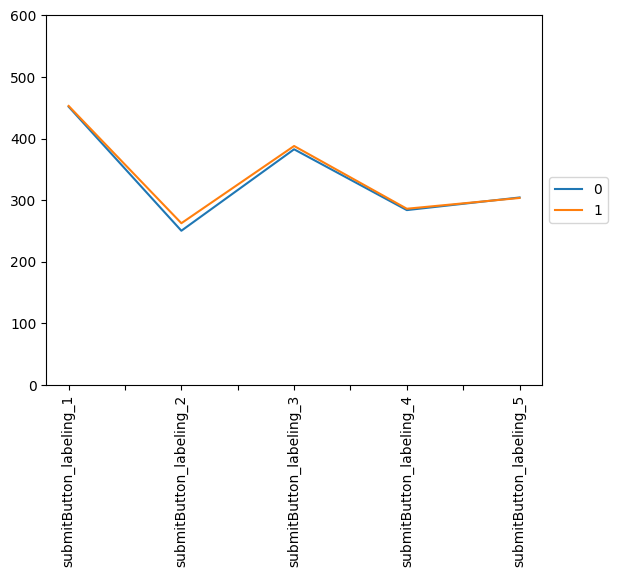

In [12]:
submit_times[[label for label in submit_times.columns if 'labeling' in label]].T.fillna(600).plot()
plt.xticks(rotation=90)
plt.ylim(0, 600)
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))

(0.0, 45.0)

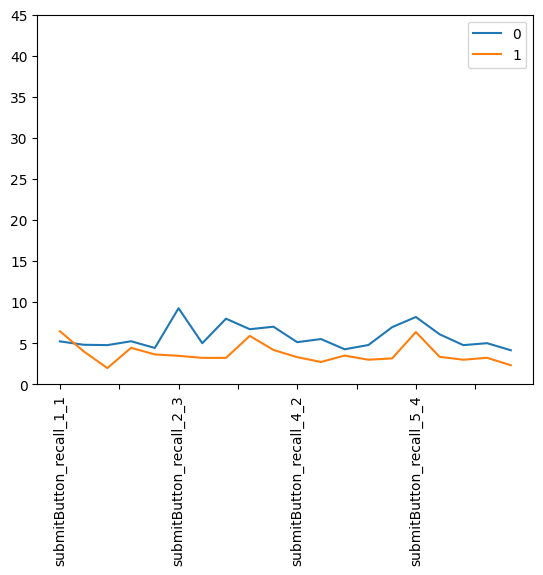

In [14]:
submit_times[[label for label in submit_times.columns if 'labeling' not in label]].T.plot()
plt.xticks(rotation=90)
plt.ylim(0, 45)

In [15]:
data[0]['prompts'].keys()

dict_keys(['prompt_recall_1_1', 'prompt_recall_1_2', 'prompt_recall_1_4', 'prompt_recall_2_2', 'prompt_recall_2_4', 'prompt_recall_3_1', 'prompt_recall_3_2', 'prompt_recall_4_2', 'prompt_recall_4_3', 'prompt_recall_4_4', 'prompt_recall_5_1', 'prompt_recall_5_2', 'prompt_labeling_1', 'prompt_labeling_2', 'prompt_labeling_3', 'prompt_labeling_4', 'prompt_labeling_5', 'prompt_recall_2_1', 'prompt_recall_5_3', 'prompt_recall_5_4', 'prompt_recall_1_3', 'prompt_recall_2_3', 'prompt_recall_3_3', 'prompt_recall_3_4', 'prompt_recall_4_1'])

In [16]:
print(data[0]['prompts']['prompt_labeling_2']['value'])

Image 1:baby
Image 2:stretch
Image 3:bird
Image 4:mouth
Image 5:chicken
Image 6:line
Image 7:stump
Image 8:bench



In [17]:
def extract_word(cell):
    pattern = r"Image \d+:\s*(\w+)\s*"
    match = re.search(pattern, str(cell), re.IGNORECASE)
    return match.group(1) if match else cell

labels1 = pd.DataFrame([row['prompts']['prompt_labeling_2']['value'].split("\n") for row in data])
labels1 = labels1.applymap(extract_word)
labels1

/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_29562/2448895090.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  labels1 = labels1.applymap(extract_word)


,0,1,2,3,4,5,6,7,8
0,baby,stretch,bird,mouth,chicken,line,stump,bench,
1,baby,stretch,bird,mouth,chicken,line,stump,bench,


In [18]:
df = pd.DataFrame({key: d['value'].split("\n") for key, d in data[0]['prompts'].items() if 'labeling' in key})

def extract_word(cell):
    pattern = r"Image \d+:\s*(\w+)\s*"
    match = re.search(pattern, str(cell), re.IGNORECASE)
    return match.group(1) if match else cell

df = df.applymap(extract_word)
df

/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_29562/1536185190.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(extract_word)


,prompt_labeling_1,prompt_labeling_2,prompt_labeling_3,prompt_labeling_4,prompt_labeling_5
0,hole,baby,yoda,closed,stand
1,tbone,stretch,legs,crab,zombie
2,hoops,bird,box,eyes,yoga
3,stretch,mouth,baby,legs,kneel
4,chicken,chicken,stick,train,crawl
5,shield,line,rectangle,toilet,bend
6,eye,stump,trash,yellow,hands
7,feet,bench,soda,cake,leg
8,,,,,


In [57]:
df = pd.DataFrame({key: d['value'].split("\n") for key, d in data[0]['prompts'].items() if 'labeling' in key})

def extract_word(cell):
    pattern = r"Image \d+:\s*(\w+)\s*"
    match = re.search(pattern, str(cell), re.IGNORECASE)
    return match.group(1) if match else cell

df = df.applymap(extract_word)
df



/var/folders/2l/3kmvzs0s1sggnw_9sl0ls8080000gn/T/ipykernel_42788/3409228478.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(extract_word)


,prompt_labeling_1,prompt_labeling_2,prompt_labeling_3,prompt_labeling_4,prompt_labeling_5
0,hole,baby,yoda,closed,stand
1,tbone,stretch,legs,crab,zombie
2,hoops,bird,box,eyes,yoga
3,stretch,mouth,baby,legs,kneel
4,chicken,chicken,stick,train,crawl
5,shield,line,rectangle,toilet,bend
6,eye,stump,trash,yellow,hands
7,feet,bench,soda,cake,leg
8,,,,,


In [63]:
recall = pd.DataFrame([{key: d['value'] for key, d in row['prompts'].items() if 'recall' in key} for row in data]).T
recall["match"] = recall[0] == recall[1]
recall

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,match
prompt_recall_1_1,D,D,beach,forest beach cityscope mountain de,NaN,NaN,NaN,2,NaN,NaN,...,NaN,Don't know,NaN,NaN,NaN,NaN,T,NaN,NaN,True
prompt_recall_1_2,2,2,NaN,beach,NaN,NaN,NaN,NaN,white,NaN,...,2,Don't know,NaN,NaN,4,NaN,Challenge,NaN,NaN,True
prompt_recall_1_4,4,4,NaN,NaN,hi,NaN,NaN,NaN,one eye robot\n,yes are you,...,6,Don't know,beach,beach,NaN,NaN,NaN,NaN,NaN,True
prompt_recall_2_2,6,6,meadow,meadow,NaN,NaN,NaN,NaN,black eye,NaN,...,b,Hopper,commer,NaN,2,NaN,NaN,NaN,NaN,True
prompt_recall_2_4,8,8,Skyline,skyline,NaN,Hopper,NaN,NaN,red short,NaN,...,g,don't know,hopper,hopper,NaN,NaN,NaN,NaN,NaN,True
prompt_recall_3_1,1,1,Grove,grove,NaN,Shoreline,NaN,NaN,u,NaN,...,a,5,NaN,b,1,NaN,mountain-peak,NaN,NaN,True
prompt_recall_3_2,6,6,Meadow,meadow,NaN,NaN,NaN,NaN,r,NaN,...,g,5,NaN,b,6,NaN,ghjghgjhjk,NaN,NaN,True
prompt_recall_4_2,5,5,Meadow,meadow,NaN,NaN,NaN,NaN,umbrella,NaN,...,Meadow,N/A,NaN,Shoreline,6,NaN,NaN,NaN,NaN,True
prompt_recall_4_3,8,8,Coastline,coastline,NaN,NaN,NaN,NaN,yellow,NaN,...,Coastline,NaN,NaN,Shoreline,7,NaN,NaN,NaN,NaN,True
prompt_recall_4_4,2,2,Wasteland,wasteland,NaN,NaN,NaN,NaN,train,NaN,...,Wasteland,NONE,NaN,Shoreline,5,NaN,NaN,NaN,NaN,True


In [68]:
browserInfo

NameError: name 'browserInfo' is not defined

In [70]:
treatments.join(connection_info).join(demographics)[["treatment", "country", "timezone", "language_primary", "english_written", "english_spoken", "country_reside", "education_US", "race_US"]].join(labels1)

,treatment,country,timezone,language_primary,english_written,english_spoken,country_reside,education_US,race_US,0,1,2,3,4,5,6,7,8,9
0,schema,BD,Asia/Dhaka,English,5.0,5.0,United States,7,[White],Hasib,Nirob,Maruf,Firoz,Sohag,suruz,Image 7:,Image 8:,,None
1,schema,BD,Asia/Dhaka,Armenian,5.0,5.0,United States,7,[White],Hasib,Nirob,Maruf,Firoz,Sohag,suruz,Image 7:,Image 8:,,None
2,schema,BD,Asia/Dhaka,English,5.0,5.0,United States,7,[White],Grove,Shoreline,Metropolis,Summit,Wasteland,Meadow,Coastline,Skyline,,
3,schema,BD,Asia/Dhaka,English,5.0,5.0,United States,7,[White],Grove,Shoreline,Metropolis,Summit,Wasteland,Meadow,Coastline,Skyline,,
4,schema,BD,Asia/Dhaka,English,5.0,4.0,United States,6,[White],Image 1:,Image 2:,Image 3:,Image 4:,Image 5:,Image 6:,Image 7:,Image 8:,,None
5,nonschema,BD,Asia/Dhaka,English,5.0,5.0,United States,7,[White],good,Image 2:,Image 3:,Image 4:,Image 5:,Image 6:,Image 7:,Image 8:,,None
6,nonschema,US,America/Denver,English,5.0,5.0,United States,7,[White],good,Image 2:,Image 3:,Image 4:,Image 5:,Image 6:,Image 7:,Image 8:,,None
7,nonschema,NaN,NaN,English,5.0,5.0,United States,7,[White],Image 1:,Image 2:,Image 3:,Image 4:,Image 5:,Image 6:,Image 7:,Image 8:,,None
8,nonschema,BD,Asia/Dhaka,English,5.0,5.0,United States,7,[White],Image 1:,Image 2:,Image 3:,Image 4:,Image 5:,Image 6:,Image 7:,Image 8:,,None
9,schema,US,America/New_York,English,5.0,5.0,United States,6,[White],Image 1:,Image 2:,Image 3:,Image 4:,Image 5:,Image 6:,Image 7:,Image 8:,,None
